# Regressione Probabilistica tramite Processi Gaussiani (GPR)

In questa fase del progetto, l'obiettivo è modellare il **comportamento nominale** del motore aeronautico per definire un riferimento di "salute" della flotta. 
E' stata utilizzata la **Regressione tramite Processi Gaussiani (GPR)** per stimare la coppia target ($Trq_{target}$) in base alle condizioni operative.

Il valore aggiunto di questo approccio è la capacità di fornire non solo una stima puntuale, ma una **distribuzione di probabilità** che permette di calcolare il **Torque Margin** e la relativa incertezza.

In [1]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path
from dataset import load_dataset
from regression.GPR.gpr_model import GPRModel
from regression.GPR.gpr_sampling import lhs_nearest_sampling
from regression.probabilistic_rf_scoring import plot_pdf_with_true_target
plt.style.use("default")
from plot_style import set_plot_style
set_plot_style()


In [2]:
ROOT_DIR = Path(os.getcwd()).parents[3]
SRC_PATH = ROOT_DIR / "src"
DATA_PATH = ROOT_DIR / "data" / "processed"
OUTPUT_PATH = ROOT_DIR / "output" / "GPR" / "model_target"
TRAIN_PATH_SPLIT= "../../../../data/processed/split_85_15/train_85.csv"
TEST_PATH_SPLIT= "../../../../data/processed/split_85_15/test_15.csv"
MODEL_FILE = OUTPUT_PATH / "gpr_model.pkl"
SCALER_FILE = OUTPUT_PATH / "scaler_gpr.pkl"
OUTPUT_CSV = OUTPUT_PATH / "test_with_features_enriched.csv"
MODEL_FILE = OUTPUT_PATH / "gpr_model_500.pkl"
SCALER_FILE = OUTPUT_PATH / "scaler_gpr.pkl"
# Aggiunta ROOT_DIR al path per permettere a joblib di trovare i moduli custom
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))


In [3]:
FEATURES = ['oat', 'mgt', 'pa', 'ias', 'np_ng_ratio', 'trq_measured']
TARGET_NAME = 'trq_target'

In [4]:
train_df=load_dataset(TRAIN_PATH_SPLIT)
test_df=load_dataset(TEST_PATH_SPLIT)

In [5]:
gpr_model = GPRModel(random_state=42)

# 2. Controllo esistenza modelli
if MODEL_FILE.exists() and SCALER_FILE.exists():
    print("Modello pre-addestrato trovato! Caricamento in corso...")
    try:
        gpr_model = joblib.load(MODEL_FILE)
        scaler = joblib.load(SCALER_FILE)
        print("SUCCESSO: Modello e Scaler caricati correttamente.")
        addestramento_necessario = False
    except Exception as e:
        print(f"Errore nel caricamento dei file (file corrotti?): {e}")
        addestramento_necessario = True
else:
    print("Modello non trovato o incompleto. Avvio procedura di addestramento...")
    addestramento_necessario = True

# 3. Addestramento (solo se necessario)
if addestramento_necessario:
    # Campionamento LHS e Normalizzazione (5000 campioni per la massima precisione)
    X_train_scaled, y_train, scaler = lhs_nearest_sampling(
        train_df, FEATURES, TARGET_NAME, n_samples=5000
    )

    # Fit del Modello GPR
    print("Addestramento GPR in corso (potrebbe richiedere qualche minuto)...")
    gpr_model.fit(X_train_scaled, y_train)

    # Salvataggio fisico
    OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
    try:
        joblib.dump(gpr_model, MODEL_FILE)
        joblib.dump(scaler, SCALER_FILE)
        print(f"SUCCESSO: Modello salvato in -> {MODEL_FILE}")
        print(f"SUCCESSO: Scaler salvato in -> {SCALER_FILE}")
    except Exception as e:
        print(f"ERRORE DURANTE IL SALVATAGGIO: {e}")

Modello pre-addestrato trovato! Caricamento in corso...
SUCCESSO: Modello e Scaler caricati correttamente.


In [6]:
test_X=scaler.fit_transform(test_df[FEATURES])
test_y=test_df[TARGET_NAME]

In [ ]:
gpr_model.evaluate(test_X,test_y)

TARGET

0.9946521055453714
1.0


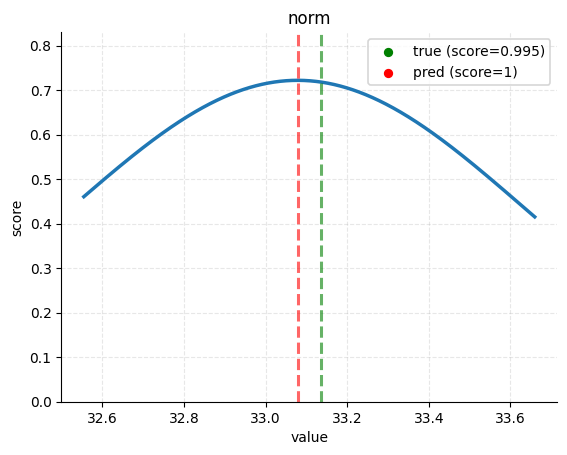

{'pdf_type': 'norm',
 'true_target': 33.13585929530154,
 'prediction': 33.07865035304676,
 'score_true': 0.9946521055453714,
 'score_pred': 1.0,
 'x_range': (32.55486604617866, 33.65964360216964)}

In [7]:
id =5682
test_row = test_X[id:id+1]
feat = "trq_measured"
j = FEATURES.index(feat)   # posizione della feature
trq_measured_test = test_X[id, j]
test_y_true = float(test_y[id])
mu, std = gpr_model.predict(test_row, return_std=True)
mu_target = float(mu[0])
std_target =float(std[0])
pdf_args = {"loc": mu_target, "scale": std_target}
plot_pdf_with_true_target("norm",pdf_args,true_target=test_y_true,y_pred=mu_target)

MARGIN

0.12471988535691036
1.0
1.0


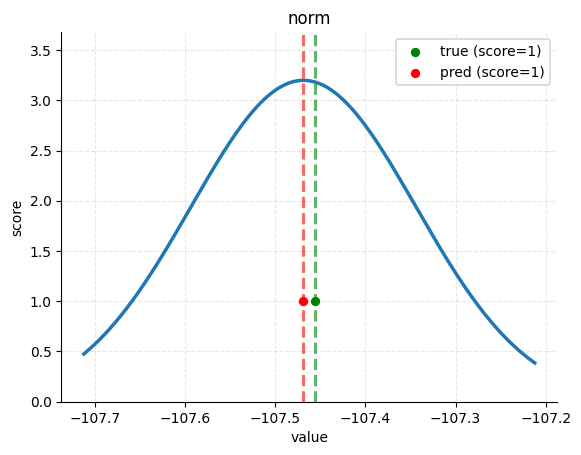

{'pdf_type': 'norm',
 'true_target': -107.45569582483365,
 'prediction': -107.46859031923894,
 'score_true': 1.0,
 'score_pred': 1.0,
 'x_range': (-107.7121430720363, -107.2121430720363)}

In [10]:
trq_margin_true=100*(trq_measured_test/test_y_true -1)
trq_margin_predetto = 100 * (trq_measured_test / mu_target - 1)
std_margin = np.abs(100 * (trq_measured_test / (mu_target**2)) * std_target)
print(std_margin)
pdf_args = {"loc": trq_margin_predetto, "scale": std_margin}
plot_pdf_with_true_target("norm",pdf_args,true_target=trq_margin_true,y_pred=trq_margin_predetto)

3.1987062789528813


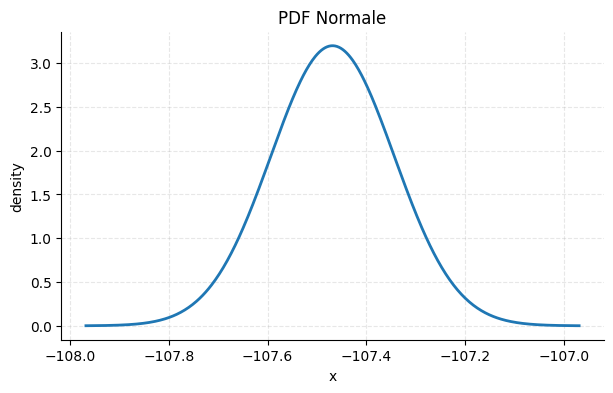

0.0
0.0


/Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/src/regression/probabilistic_rf_scoring.py:370: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(0.0, y_max_plot * 1.15)


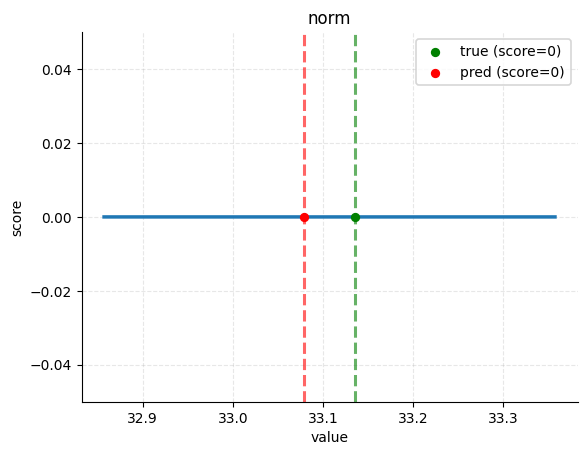

{'pdf_type': 'norm',
 'true_target': 33.13585929530154,
 'prediction': 33.07865035304676,
 'score_true': 0.0,
 'score_pred': 0.0,
 'x_range': (32.85725482417415, 33.35725482417415)}

In [15]:
id =5682
test_row = test_X[id:id+1]
test_y_true = float(test_y[id])
mu, std = gpr_model.predict(test_row, return_std=True)
mu = float(mu[0])
std=float(std[0])

dist=stats.norm(trq_margin_predetto,std_margin)
max_pdf = 1 / (std_margin * np.sqrt(2*np.pi))
print(max_pdf)
# range di x (tipicamente ±4 sigma)
x = np.linspace(trq_margin_predetto - 4*std_margin, trq_margin_predetto + 4*std_margin, 500)

# PDF
y = dist.pdf(x)

# plot
plt.figure(figsize=(7,4))
plt.plot(x, y, linewidth=2)

plt.title("PDF Normale")
plt.xlabel("x")
plt.ylabel("density")
plt.grid(alpha=0.3)
plt.show()

pdf_args = {"loc": trq_margin_predetto, "scale": std_margin}
plot_pdf_with_true_target("norm",pdf_args,true_target=test_y_true,y_pred=mu)

In [ ]:
# --- ANALISI PROBABILISTICA MONTE CARLO (VERSIONE FINALE) ---

# 1. Impostazione indice e recupero dati
idx = 100 
flight_data = df_results.iloc[[idx]]
flight_id = int(flight_data['id'].values[0])

# 2. Generazione campioni dal modello GPR
# Scaliamo le feature della riga selezionata
X_single_scaled = scaler.transform(flight_data[FEATURES])

# Campionamento stocastico (5000 estrazioni)
y_trq_samples = gpr_obj.sample_y(X_single_scaled, n_sample=5000).flatten()

# Trasformazione in Torque Margin (%)
trq_meas = flight_data['trq_measured'].values[0]
margin_samples = 100 * (trq_meas / y_trq_samples - 1)

# 3. Calcolo Statistiche Empiriche (Monte Carlo)
mu_mc = np.mean(margin_samples)
var_mc = np.var(margin_samples)
std_mc = np.std(margin_samples)
# Intervallo di Confidenza 95% (calcolato sui percentili reali dei campioni)
ci_lower = np.percentile(margin_samples, 2.5)
ci_upper = np.percentile(margin_samples, 97.5)

# 4. Grafico
plt.figure(figsize=(10, 6))

# Istogramma dei campioni
plt.hist(margin_samples, bins=60, density=True, alpha=0.3, color='blue', 
         edgecolor='white', label='Distribuzione Campioni GPR')

# PDF Empirica (Curva che segue i campioni)
x_range = np.linspace(ci_lower - std_mc, ci_upper + std_mc, 500)
plt.plot(x_range, stats.norm.pdf(x_range, mu_mc, std_mc), color='blue', lw=2, label='Densità Probabilità (MC)')

# Linea della Media
plt.axvline(mu_mc, color='red', linestyle='--', lw=2, label=f'Media: {mu_mc:.2f}%')

# Area di Confidenza 95%
plt.fill_between(x_range, stats.norm.pdf(x_range, mu_mc, std_mc), 
                 where=(x_range >= ci_lower) & (x_range <= ci_upper), 
                 color='blue', alpha=0.1, label='Area Confidenza 95%')

plt.title(f'Analisi Probabilistica -  {flight_id}')
plt.xlabel('Torque Margin (%)')
plt.ylabel('Densità')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# 5. Tabella Statistica Riassuntiva
stats_data = {
    "Parametro": [
        "ID ", 
        "Media Margine (μ)", 
        "Varianza (σ²)", 
        "Deviazione Standard (σ)", 
        "Intervallo Confidenza (95%)"
    ],
    "Valore": [
        flight_id, 
        f"{mu_mc:.4f}", 
        f"{var_mc:.6f}", 
        f"{std_mc:.4f}", 
        f"[{ci_lower:.2f} , {ci_upper:.2f}]"
    ]
}

df_stats = pd.DataFrame(stats_data)
display(df_stats)